In [4]:
import cv2
import numpy as np
from pathlib import Path

img1 = cv2.imread('./img1.jpg', cv2.IMREAD_GRAYSCALE)

template = img1[100:300, 100:300]

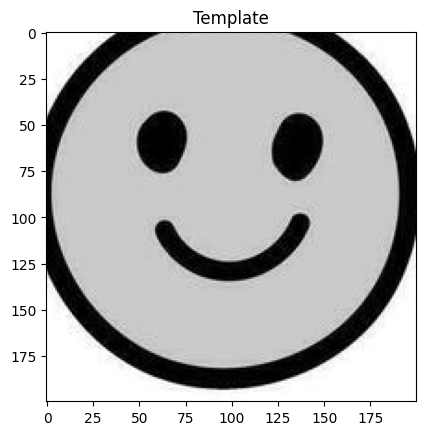

In [6]:
import matplotlib.pyplot as plt


plt.imshow(template, cmap='gray')
plt.title('Template')
plt.show()

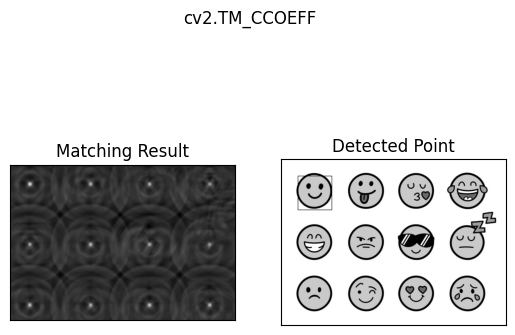

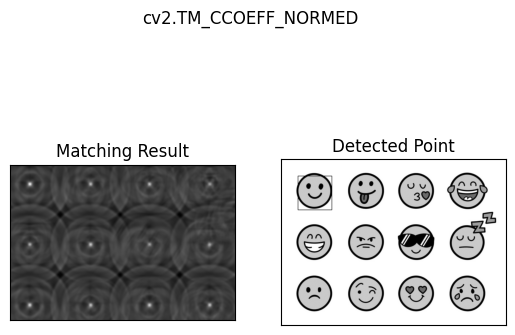

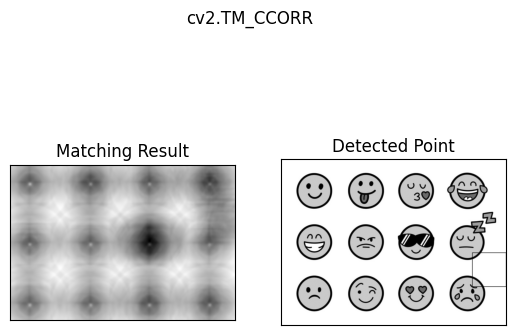

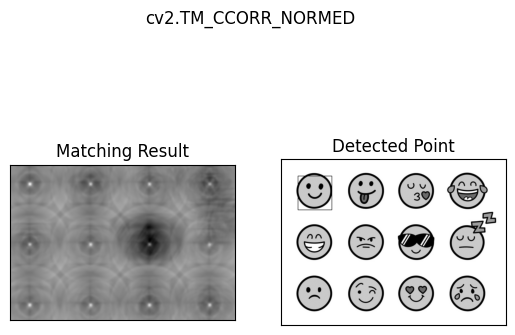

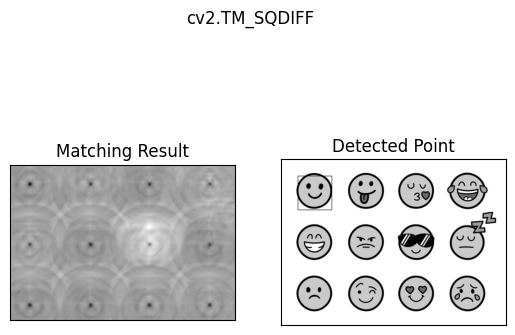

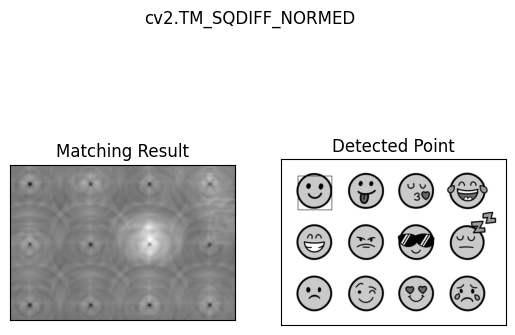

In [7]:
w, h = template.shape[::-1]
methods = ['cv2.TM_CCOEFF',
           'cv2.TM_CCOEFF_NORMED',
           'cv2.TM_CCORR',
           'cv2.TM_CCORR_NORMED',
           'cv2.TM_SQDIFF',
           'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    input = img1.copy()
    method = eval(meth)
    res = cv2.matchTemplate(img1, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv2.rectangle(input, top_left, bottom_right, 0, 2)
    plt.figure()
    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(input, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)
plt.show()